1. Downloading dataset directly from UCI Repository...

Dataset loaded successfully!
Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

2. Preprocessing text data...

3. Data split successfully: 4457 training samples, 1115 testing samples.

4. Converting text to numerical features using TF-IDF Vectorizer...

--- Multinomial Naive Bayes Evaluation ---
Accuracy : 0.9722
Precision: 1.0000
Recall   : 0.7919
F1-Score : 0.8839

--- Logistic Regression Evaluation ---
Accuracy : 0.9686
Precision: 1.0000
Recall   : 0.7651
F1-Score : 0.8669

--- Model Performance Comparison ---
                  Model  Accuracy  Precision   Recall  F1-Score
Multinomial Naive Bayes  0.972197        1.0 0.791946  0.883895
    Logistic Regression  0.968610        1.0 0.765101  0.866920


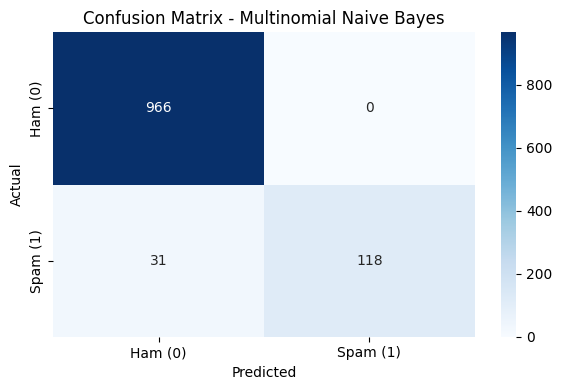


--- Sample Live Testing ---
Message: 'URGENT! You have won a $1,000 Walmart gift card. Click here to claim NOW!' --> Prediction: SPAM
Message: 'Hey, are we still meeting for lunch today at 1 PM?' --> Prediction: HAM (Legitimate)


In [2]:
# ==========================================
# Oasis Infobyte - Data Science Internship
# Task 4: Email / SMS Spam Detection (NLP)
# ==========================================

import io
import re
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("1. Downloading dataset directly from UCI Repository...")
# Direct link to the official SMS Spam Collection zip file
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

req = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(req.read()))

# Extract and read the tab-separated dataset file
with zip_file.open('SMSSpamCollection') as f:
    df = pd.read_csv(f, sep='\t', names=['label', 'message'], encoding='utf-8')

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())

# Step 2: Preprocessing Text
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Remove punctuation & special characters
    return text

print("\n2. Preprocessing text data...")
df['clean_message'] = df['message'].apply(clean_text)

# Encode Labels: ham -> 0, spam -> 1
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

# Step 3: Train-Test Split (80/20)[cite: 1]
X = df['clean_message']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\n3. Data split successfully: {len(X_train)} training samples, {len(X_test)} testing samples.")

# Step 4: TF-IDF Vectorization[cite: 1]
print("\n4. Converting text to numerical features using TF-IDF Vectorizer...")
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Step 5: Model 1 - Multinomial Naive Bayes[cite: 1]
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# Step 6: Model 2 - Logistic Regression[cite: 1]
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

# Step 7: Evaluation & Comparison[cite: 1]
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n--- {name} Evaluation ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    return [name, acc, prec, rec, f1]

results = []
results.append(evaluate_model("Multinomial Naive Bayes", y_test, y_pred_nb))
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))

# Display Comparison Table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n--- Model Performance Comparison ---")
print(results_df.to_string(index=False))

# Step 8: Visualization - Confusion Matrix[cite: 1]
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham (0)', 'Spam (1)'], yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Step 9: Sample Prediction Test
sample_messages = [
    "URGENT! You have won a $1,000 Walmart gift card. Click here to claim NOW!",
    "Hey, are we still meeting for lunch today at 1 PM?"
]

sample_tfidf = tfidf.transform([clean_text(m) for m in sample_messages])
predictions = nb_model.predict(sample_tfidf)

print("\n--- Sample Live Testing ---")
for msg, pred in zip(sample_messages, predictions):
    status = "SPAM" if pred == 1 else "HAM (Legitimate)"
    print(f"Message: '{msg}' --> Prediction: {status}")